In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/Weather_Forecasting.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (231312, 16)


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nCities:")
print(df["city"].value_counts())

print("\nDate range:")
print("Start:", df["time"].min())
print("End:", df["time"].max())

Shape: (231312, 16)

Columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'city', 'state', 'latitude', 'longitude']

Data types:
time                     object
temperature_2m          float64
relative_humidity_2m      int64
dew_point_2m            float64
apparent_temperature    float64
precipitation           float64
rain                    float64
surface_pressure        float64
cloud_cover               int64
wind_speed_10m          float64
wind_direction_10m        int64
wind_gusts_10m          float64
city                     object
state                    object
latitude                float64
longitude               float64
dtype: object

Missing values:
time                    0
temperature_2m          0
relative_humidity_2m    0
dew_point_2m            0
apparent_temperature    0
precipitation           0
rain   

In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
time                    0
temperature_2m          0
relative_humidity_2m    0
dew_point_2m            0
apparent_temperature    0
precipitation           0
rain                    0
surface_pressure        0
cloud_cover             0
wind_speed_10m          0
wind_direction_10m      0
wind_gusts_10m          0
city                    0
state                   0
latitude                0
longitude               0
dtype: int64

Total missing values: 0

Duplicate rows: 23952


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

print("\nDuplicates by city:")
print(
    df[df.duplicated(keep=False)]["city"]
    .value_counts()
)

print("\nRows per city:")
print(df["city"].value_counts())

Duplicate rows: 23952

Duplicates by city:
city
Bhopal    47904
Name: count, dtype: int64

Rows per city:
city
Bhopal       65424
Delhi        41472
Mumbai       41472
Bengaluru    41472
Chennai      41472
Name: count, dtype: int64


In [ ]:
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 231312
Rows after removing duplicates: 207360
Duplicates removed: 23952


In [ ]:
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

print("Rows before:", before)
print("Rows after:", len(df))
print("Duplicates removed:", before - len(df))

Rows before: 207360
Rows after: 207360
Duplicates removed: 0


In [ ]:
print("\nRows per city:")
print(df["city"].value_counts())

print("\nRemaining duplicates:")
print(df.duplicated().sum())


Rows per city:
city
Delhi        41472
Mumbai       41472
Bengaluru    41472
Chennai      41472
Bhopal       41472
Name: count, dtype: int64

Remaining duplicates:
0


In [ ]:
print("Total rows:", len(df))
print("\nRows per city:")
print(df["city"].value_counts())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum())

Total rows: 207360

Rows per city:
city
Bengaluru    41472
Bhopal       41472
Chennai      41472
Delhi        41472
Mumbai       41472
Name: count, dtype: int64

Duplicate rows: 0

Missing values:
time                      0
temperature_2m            0
relative_humidity_2m      0
dew_point_2m              0
apparent_temperature      0
precipitation             0
rain                      0
surface_pressure          0
cloud_cover               0
wind_speed_10m            0
wind_direction_10m        0
wind_gusts_10m            0
city                      0
state                     0
latitude                  0
longitude                 0
hour                      0
day                       0
month                     0
year                      0
day_of_year               0
hour_sin                  0
hour_cos                  0
month_sin                 0
month_cos                 0
wind_direction_sin        0
wind_direction_cos        0
target_temperature        5
temp_lag_1         

In [ ]:
print("Model dataset shape:", model_df.shape)
print("\nMissing values in model_df:")
print(model_df.isnull().sum().sum())

print("\nDuplicates in model_df:")
print(model_df.duplicated().sum())

Model dataset shape: (207235, 37)

Missing values in model_df:
0

Duplicates in model_df:
0


In [ ]:
df["time"] = pd.to_datetime(df["time"])

print(df["time"].dtype)
print(df[["time", "city"]].head())

datetime64[ns]
                 time   city
0 2022-01-01 00:00:00  Delhi
1 2022-01-01 01:00:00  Delhi
2 2022-01-01 02:00:00  Delhi
3 2022-01-01 03:00:00  Delhi
4 2022-01-01 04:00:00  Delhi


In [ ]:
df = df.sort_values(
    by=["city", "time"]
).reset_index(drop=True)

print("Dataset sorted successfully!")

print(df[["city", "time"]].head(10))

Dataset sorted successfully!
        city                time
0  Bengaluru 2022-01-01 00:00:00
1  Bengaluru 2022-01-01 01:00:00
2  Bengaluru 2022-01-01 02:00:00
3  Bengaluru 2022-01-01 03:00:00
4  Bengaluru 2022-01-01 04:00:00
5  Bengaluru 2022-01-01 05:00:00
6  Bengaluru 2022-01-01 06:00:00
7  Bengaluru 2022-01-01 07:00:00
8  Bengaluru 2022-01-01 08:00:00
9  Bengaluru 2022-01-01 09:00:00


In [ ]:
for city in df["city"].unique():
    city_df = df[df["city"] == city]

    is_sorted = city_df["time"].is_monotonic_increasing

    print(city, "→ Sorted:", is_sorted)

Bengaluru → Sorted: True
Bhopal → Sorted: True
Chennai → Sorted: True
Delhi → Sorted: True
Mumbai → Sorted: True


In [ ]:
for city in df["city"].unique():
    city_df = df[df["city"] == city].copy()

    time_diff = city_df["time"].diff()

    missing_hours = (time_diff > pd.Timedelta(hours=1)).sum()

    print(city, "→ Missing hourly gaps:", missing_hours)

Bengaluru → Missing hourly gaps: 0
Bhopal → Missing hourly gaps: 0
Chennai → Missing hourly gaps: 0
Delhi → Missing hourly gaps: 0
Mumbai → Missing hourly gaps: 0


In [ ]:
df["hour"] = df["time"].dt.hour
df["day"] = df["time"].dt.day
df["month"] = df["time"].dt.month
df["year"] = df["time"].dt.year
df["day_of_year"] = df["time"].dt.dayofyear

print(df[[
    "time",
    "hour",
    "day",
    "month",
    "year",
    "day_of_year"
]].head(10))

                 time  hour  day  month  year  day_of_year
0 2022-01-01 00:00:00     0    1      1  2022            1
1 2022-01-01 01:00:00     1    1      1  2022            1
2 2022-01-01 02:00:00     2    1      1  2022            1
3 2022-01-01 03:00:00     3    1      1  2022            1
4 2022-01-01 04:00:00     4    1      1  2022            1
5 2022-01-01 05:00:00     5    1      1  2022            1
6 2022-01-01 06:00:00     6    1      1  2022            1
7 2022-01-01 07:00:00     7    1      1  2022            1
8 2022-01-01 08:00:00     8    1      1  2022            1
9 2022-01-01 09:00:00     9    1      1  2022            1


In [ ]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

print(df[[
    "time",
    "hour",
    "hour_sin",
    "hour_cos",
    "month",
    "month_sin",
    "month_cos"
]].head(10))

                 time  hour  hour_sin      hour_cos  month  month_sin  \
0 2022-01-01 00:00:00     0  0.000000  1.000000e+00      1        0.5   
1 2022-01-01 01:00:00     1  0.258819  9.659258e-01      1        0.5   
2 2022-01-01 02:00:00     2  0.500000  8.660254e-01      1        0.5   
3 2022-01-01 03:00:00     3  0.707107  7.071068e-01      1        0.5   
4 2022-01-01 04:00:00     4  0.866025  5.000000e-01      1        0.5   
5 2022-01-01 05:00:00     5  0.965926  2.588190e-01      1        0.5   
6 2022-01-01 06:00:00     6  1.000000  6.123234e-17      1        0.5   
7 2022-01-01 07:00:00     7  0.965926 -2.588190e-01      1        0.5   
8 2022-01-01 08:00:00     8  0.866025 -5.000000e-01      1        0.5   
9 2022-01-01 09:00:00     9  0.707107 -7.071068e-01      1        0.5   

   month_cos  
0   0.866025  
1   0.866025  
2   0.866025  
3   0.866025  
4   0.866025  
5   0.866025  
6   0.866025  
7   0.866025  
8   0.866025  
9   0.866025  


In [ ]:
df["wind_direction_sin"] = np.sin(
    2 * np.pi * df["wind_direction_10m"] / 360
)

df["wind_direction_cos"] = np.cos(
    2 * np.pi * df["wind_direction_10m"] / 360
)

print(df[[
    "wind_direction_10m",
    "wind_direction_sin",
    "wind_direction_cos"
]].head(10))

   wind_direction_10m  wind_direction_sin  wind_direction_cos
0                  85            0.996195            0.087156
1                  85            0.996195            0.087156
2                  81            0.987688            0.156434
3                  78            0.978148            0.207912
4                  76            0.970296            0.241922
5                  74            0.961262            0.275637
6                  72            0.951057            0.309017
7                  76            0.970296            0.241922
8                  77            0.974370            0.224951
9                  78            0.978148            0.207912


In [ ]:
df["target_temperature"] = (
    df.groupby("city")["temperature_2m"]
    .shift(-1)
)

print(df[[
    "city",
    "time",
    "temperature_2m",
    "target_temperature"
]].head(10))

        city                time  temperature_2m  target_temperature
0  Bengaluru 2022-01-01 00:00:00            18.3                18.9
1  Bengaluru 2022-01-01 01:00:00            18.9                18.8
2  Bengaluru 2022-01-01 02:00:00            18.8                18.7
3  Bengaluru 2022-01-01 03:00:00            18.7                18.6
4  Bengaluru 2022-01-01 04:00:00            18.6                18.5
5  Bengaluru 2022-01-01 05:00:00            18.5                18.7
6  Bengaluru 2022-01-01 06:00:00            18.7                18.6
7  Bengaluru 2022-01-01 07:00:00            18.6                19.8
8  Bengaluru 2022-01-01 08:00:00            19.8                21.8
9  Bengaluru 2022-01-01 09:00:00            21.8                23.4


In [ ]:
print("Missing target values:", df["target_temperature"].isna().sum())

print(
    df[df["target_temperature"].isna()][
        ["city", "time", "temperature_2m", "target_temperature"]
    ]
)

Missing target values: 5
             city                time  temperature_2m  target_temperature
41471   Bengaluru 2026-09-24 23:00:00            21.5                 NaN
82943      Bhopal 2026-09-24 23:00:00            24.4                 NaN
124415    Chennai 2026-09-24 23:00:00            29.0                 NaN
165887      Delhi 2026-09-24 23:00:00            27.7                 NaN
207359     Mumbai 2026-09-24 23:00:00            27.8                 NaN


In [ ]:
# Create temperature lag features for each city

df["temp_lag_1"] = (
    df.groupby("city")["temperature_2m"]
    .shift(1)
)

df["temp_lag_3"] = (
    df.groupby("city")["temperature_2m"]
    .shift(3)
)

df["temp_lag_6"] = (
    df.groupby("city")["temperature_2m"]
    .shift(6)
)

df["temp_lag_24"] = (
    df.groupby("city")["temperature_2m"]
    .shift(24)
)

print(df[[
    "city",
    "time",
    "temperature_2m",
    "temp_lag_1",
    "temp_lag_3",
    "temp_lag_6",
    "temp_lag_24",
    "target_temperature"
]].head(30))

         city                time  temperature_2m  temp_lag_1  temp_lag_3  \
0   Bengaluru 2022-01-01 00:00:00            18.3         NaN         NaN   
1   Bengaluru 2022-01-01 01:00:00            18.9        18.3         NaN   
2   Bengaluru 2022-01-01 02:00:00            18.8        18.9         NaN   
3   Bengaluru 2022-01-01 03:00:00            18.7        18.8        18.3   
4   Bengaluru 2022-01-01 04:00:00            18.6        18.7        18.9   
5   Bengaluru 2022-01-01 05:00:00            18.5        18.6        18.8   
6   Bengaluru 2022-01-01 06:00:00            18.7        18.5        18.7   
7   Bengaluru 2022-01-01 07:00:00            18.6        18.7        18.6   
8   Bengaluru 2022-01-01 08:00:00            19.8        18.6        18.5   
9   Bengaluru 2022-01-01 09:00:00            21.8        19.8        18.7   
10  Bengaluru 2022-01-01 10:00:00            23.4        21.8        18.6   
11  Bengaluru 2022-01-01 11:00:00            24.5        23.4        19.8   

In [ ]:
# Create lag features for humidity and pressure

df["humidity_lag_1"] = (
    df.groupby("city")["relative_humidity_2m"]
    .shift(1)
)

df["pressure_lag_1"] = (
    df.groupby("city")["surface_pressure"]
    .shift(1)
)

print(df[[
    "city",
    "time",
    "relative_humidity_2m",
    "humidity_lag_1",
    "surface_pressure",
    "pressure_lag_1"
]].head(15))

         city                time  relative_humidity_2m  humidity_lag_1  \
0   Bengaluru 2022-01-01 00:00:00                    95             NaN   
1   Bengaluru 2022-01-01 01:00:00                    90            95.0   
2   Bengaluru 2022-01-01 02:00:00                    91            90.0   
3   Bengaluru 2022-01-01 03:00:00                    91            91.0   
4   Bengaluru 2022-01-01 04:00:00                    92            91.0   
5   Bengaluru 2022-01-01 05:00:00                    92            92.0   
6   Bengaluru 2022-01-01 06:00:00                    92            92.0   
7   Bengaluru 2022-01-01 07:00:00                    95            92.0   
8   Bengaluru 2022-01-01 08:00:00                    86            95.0   
9   Bengaluru 2022-01-01 09:00:00                    74            86.0   
10  Bengaluru 2022-01-01 10:00:00                    66            74.0   
11  Bengaluru 2022-01-01 11:00:00                    60            66.0   
12  Bengaluru 2022-01-01 

In [ ]:
# Create rolling temperature features

df["temp_rolling_mean_3"] = (
    df.groupby("city")["temperature_2m"]
    .transform(lambda x: x.rolling(window=3).mean())
)

df["temp_rolling_mean_6"] = (
    df.groupby("city")["temperature_2m"]
    .transform(lambda x: x.rolling(window=6).mean())
)

df["temp_rolling_std_6"] = (
    df.groupby("city")["temperature_2m"]
    .transform(lambda x: x.rolling(window=6).std())
)

print(df[[
    "city",
    "time",
    "temperature_2m",
    "temp_rolling_mean_3",
    "temp_rolling_mean_6",
    "temp_rolling_std_6"
]].head(15))

         city                time  temperature_2m  temp_rolling_mean_3  \
0   Bengaluru 2022-01-01 00:00:00            18.3                  NaN   
1   Bengaluru 2022-01-01 01:00:00            18.9                  NaN   
2   Bengaluru 2022-01-01 02:00:00            18.8            18.666667   
3   Bengaluru 2022-01-01 03:00:00            18.7            18.800000   
4   Bengaluru 2022-01-01 04:00:00            18.6            18.700000   
5   Bengaluru 2022-01-01 05:00:00            18.5            18.600000   
6   Bengaluru 2022-01-01 06:00:00            18.7            18.600000   
7   Bengaluru 2022-01-01 07:00:00            18.6            18.600000   
8   Bengaluru 2022-01-01 08:00:00            19.8            19.033333   
9   Bengaluru 2022-01-01 09:00:00            21.8            20.066667   
10  Bengaluru 2022-01-01 10:00:00            23.4            21.666667   
11  Bengaluru 2022-01-01 11:00:00            24.5            23.233333   
12  Bengaluru 2022-01-01 12:00:00     

In [ ]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(
    df[[
        "target_temperature",
        "temp_lag_1",
        "temp_lag_3",
        "temp_lag_6",
        "temp_lag_24",
        "humidity_lag_1",
        "pressure_lag_1",
        "temp_rolling_mean_3",
        "temp_rolling_mean_6",
        "temp_rolling_std_6"
    ]].isna().sum()
)

Dataset shape: (207360, 37)

Columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'city', 'state', 'latitude', 'longitude', 'hour', 'day', 'month', 'year', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wind_direction_sin', 'wind_direction_cos', 'target_temperature', 'temp_lag_1', 'temp_lag_3', 'temp_lag_6', 'temp_lag_24', 'humidity_lag_1', 'pressure_lag_1', 'temp_rolling_mean_3', 'temp_rolling_mean_6', 'temp_rolling_std_6']

Missing values:
target_temperature       5
temp_lag_1               5
temp_lag_3              15
temp_lag_6              30
temp_lag_24            120
humidity_lag_1           5
pressure_lag_1           5
temp_rolling_mean_3     10
temp_rolling_mean_6     25
temp_rolling_std_6      25
dtype: int64


In [ ]:
model_df = df.dropna().copy()

print("Original shape:", df.shape)
print("Model dataset shape:", model_df.shape)

print("\nMissing values after cleaning:")
print(model_df.isna().sum().sum())

Original shape: (207360, 37)
Model dataset shape: (207235, 37)

Missing values after cleaning:
0


In [ ]:
features = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "surface_pressure",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "wind_direction_sin",
    "wind_direction_cos",
    "temp_lag_1",
    "temp_lag_3",
    "temp_lag_6",
    "temp_lag_24",
    "humidity_lag_1",
    "pressure_lag_1",
    "temp_rolling_mean_3",
    "temp_rolling_mean_6",
    "temp_rolling_std_6"
]

target = "target_temperature"

X = model_df[features]
y = model_df[target]

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 25
X shape: (207235, 25)
y shape: (207235,)


In [ ]:
train_df = model_df[model_df["year"] <= 2024].copy()
val_df = model_df[model_df["year"] == 2025].copy()
test_df = model_df[model_df["year"] == 2026].copy()

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining years:", train_df["year"].min(), "-", train_df["year"].max())
print("Validation year:", val_df["year"].unique())
print("Testing year:", test_df["year"].unique())

Training shape: (131400, 37)
Validation shape: (43800, 37)
Testing shape: (32035, 37)

Training years: 2022 - 2024
Validation year: [2025]
Testing year: [2026]


In [ ]:
X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (131400, 25)
y_train: (131400,)
X_val: (43800, 25)
y_val: (43800,)
X_test: (32035, 25)
y_test: (32035,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (131400, 25)
X_val_scaled: (43800, 25)
X_test_scaled: (32035, 25)


In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
y_val_pred = linear_model.predict(X_val_scaled)
y_test_pred = linear_model.predict(X_test_scaled)

print("Validation predictions:", y_val_pred.shape)
print("Test predictions:", y_test_pred.shape)

Validation predictions: (43800,)
Test predictions: (32035,)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Validation metrics
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

# Test metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Linear Regression - Validation Results")
print("---------------------------------------")
print("MAE :", val_mae)
print("RMSE:", val_rmse)
print("R²  :", val_r2)

print("\nLinear Regression - Test Results")
print("--------------------------------")
print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

Linear Regression - Validation Results
---------------------------------------
MAE : 0.4657861365435853
RMSE: 0.6715954551532495
R²  : 0.984645685586386

Linear Regression - Test Results
--------------------------------
MAE : 0.5060708432759518
RMSE: 0.7219107198355605
R²  : 0.9828191460902485


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
rf_val_pred = rf_model.predict(X_val)
rf_test_pred = rf_model.predict(X_test)

print("Validation predictions:", rf_val_pred.shape)
print("Test predictions:", rf_test_pred.shape)

Validation predictions: (43800,)
Test predictions: (32035,)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Validation metrics
rf_val_mae = mean_absolute_error(y_val, rf_val_pred)
rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_val_r2 = r2_score(y_val, rf_val_pred)

# Test metrics
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest - Validation Results")
print("----------------------------------")
print("MAE :", rf_val_mae)
print("RMSE:", rf_val_rmse)
print("R²  :", rf_val_r2)

print("\nRandom Forest - Test Results")
print("----------------------------")
print("MAE :", rf_test_mae)
print("RMSE:", rf_test_rmse)
print("R²  :", rf_test_r2)

Random Forest - Validation Results
----------------------------------
MAE : 0.36799344748858465
RMSE: 0.5745582824099265
R²  : 0.9887621530907312

Random Forest - Test Results
----------------------------
MAE : 0.43257165600124864
RMSE: 0.6585554425340457
R²  : 0.9857024228094697


In [ ]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 10.5 MB/s eta 0:00:10
   - -------------------------------------- 3.4/101.7 MB 9.1 MB/s eta 0:00:11
   -- ------------------------------------- 5.8/101.7 MB 9.8 MB/s eta 0:00:10
   --- ------------------------------------ 8.1/101.7 MB 10.3 MB/s eta 0:00:10
   ---- ----------------------------------- 10.5/101.7 MB 10.2 MB/s eta 0:00:09
   ---- ----------------------------------- 12.6/101.7 MB 10.4 MB/s eta 0:00:09
   ----- ---------------------------------- 14.4/101.7 MB 10.2 MB/s eta 0:00:09
   ------ --------------------------------- 16.3/101.7 MB 9.9 MB/s eta 0:00:09
   ------- -------------------------------- 18.6/101.7 MB 10.0 MB/s eta 0:00:09
   -------- ------------------------------- 20.7/101.7 MB 10.1 MB/s eta 0:00:09
   -------- ------------------------------- 21.8/101.7 MB 9.6 MB/s eta 0:00:09
   --------- ------------------------------ 23.3/101.7 MB

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [ ]:
xgb_val_pred = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

print("Validation predictions:", xgb_val_pred.shape)
print("Test predictions:", xgb_test_pred.shape)

Validation predictions: (43800,)
Test predictions: (32035,)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Validation metrics
xgb_val_mae = mean_absolute_error(y_val, xgb_val_pred)
xgb_val_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
xgb_val_r2 = r2_score(y_val, xgb_val_pred)

# Test metrics
xgb_test_mae = mean_absolute_error(y_test, xgb_test_pred)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

print("XGBoost - Validation Results")
print("----------------------------")
print("MAE :", xgb_val_mae)
print("RMSE:", xgb_val_rmse)
print("R²  :", xgb_val_r2)

print("\nXGBoost - Test Results")
print("----------------------")
print("MAE :", xgb_test_mae)
print("RMSE:", xgb_test_rmse)
print("R²  :", xgb_test_r2)

XGBoost - Validation Results
----------------------------
MAE : 0.3814339038378572
RMSE: 0.5788273000688924
R²  : 0.9885945363459508

XGBoost - Test Results
----------------------
MAE : 0.4371238156267014
RMSE: 0.6490346122222225
R²  : 0.9861128387279079


In [ ]:
ml_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Validation MAE": [
        val_mae,
        rf_val_mae,
        xgb_val_mae
    ],
    "Validation RMSE": [
        val_rmse,
        rf_val_rmse,
        xgb_val_rmse
    ],
    "Validation R2": [
        val_r2,
        rf_val_r2,
        xgb_val_r2
    ],
    "Test MAE": [
        test_mae,
        rf_test_mae,
        xgb_test_mae
    ],
    "Test RMSE": [
        test_rmse,
        rf_test_rmse,
        xgb_test_rmse
    ],
    "Test R2": [
        test_r2,
        rf_test_r2,
        xgb_test_r2
    ]
})

ml_results

,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Linear Regression,0.465786,0.671595,0.984646,0.506071,0.721911,0.982819
1,Random Forest,0.367993,0.574558,0.988762,0.432572,0.658555,0.985702
2,XGBoost,0.381434,0.578827,0.988595,0.437124,0.649035,0.986113


In [ ]:
%pip install tensorflow


  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.6 MB 5.6 MB/s eta 0:01:03
   ---------------------------------------- 1.3/350.6 MB 3.7 MB/s eta 0:01:34
   ---------------------------------------- 2.1/350.6 MB 3.8 MB/s eta 0:01:33
   ---------------------------------------- 3.4/350.6 MB 4.4 MB/s eta 0:01:20

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
TIME_STEPS = 24

def create_sequences(X, y, time_steps):
    X_seq = []
    y_seq = []

    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])
        y_seq.append(y.iloc[i])

    return np.array(X_seq), np.array(y_seq)


X_train_lstm, y_train_lstm = create_sequences(
    X_train_scaled, y_train, TIME_STEPS
)

X_val_lstm, y_val_lstm = create_sequences(
    X_val_scaled, y_val, TIME_STEPS
)

X_test_lstm, y_test_lstm = create_sequences(
    X_test_scaled, y_test, TIME_STEPS
)

print("X_train_lstm:", X_train_lstm.shape)
print("y_train_lstm:", y_train_lstm.shape)

print("X_val_lstm:", X_val_lstm.shape)
print("y_val_lstm:", y_val_lstm.shape)

print("X_test_lstm:", X_test_lstm.shape)
print("y_test_lstm:", y_test_lstm.shape)

X_train_lstm: (131376, 24, 25)
y_train_lstm: (131376,)
X_val_lstm: (43776, 24, 25)
y_val_lstm: (43776,)
X_test_lstm: (32011, 24, 25)
y_test_lstm: (32011,)


In [ ]:
lstm_model = Sequential([
    LSTM(64, input_shape=(TIME_STEPS, X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

c:\Users\mayan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,153 (98.25 KB)

 Trainable params: 25,153 (98.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - loss: 18.2053 - mae: 2.2515 - val_loss: 0.7678 - val_mae: 0.6115
Epoch 2/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 47s 23ms/step - loss: 3.1098 - mae: 1.3710 - val_loss: 1.0355 - val_mae: 0.8024
Epoch 3/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 55s 27ms/step - loss: 2.2535 - mae: 1.1538 - val_loss: 0.7014 - val_mae: 0.5923
Epoch 4/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 45s 22ms/step - loss: 1.4964 - mae: 0.9238 - val_loss: 0.6590 - val_mae: 0.5601
Epoch 5/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - loss: 1.0924 - mae: 0.7717 - val_loss: 0.7368 - val_mae: 0.6275
Epoch 6/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 45s 22ms/step - loss: 0.9179 - mae: 0.6969 - val_loss: 0.7675 - val_mae: 0.6528
Epoch 7/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - loss: 0.8345 - mae: 0.6593 - val_loss: 0.6244 - val_mae: 0.5582
Epoch 8/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.7848 - mae: 0.6366 - val_loss: 0.7255 - val_mae: 0.6217
Epoch 9/20
2053/2053 ━━

In [ ]:
print("Epochs completed:", len(history.history["loss"]))

print("\nFinal Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

print("\nFinal Training MAE:", history.history["mae"][-1])
print("Final Validation MAE:", history.history["val_mae"][-1])

Epochs completed: 10

Final Training Loss: 0.7340100407600403
Final Validation Loss: 0.6556628346443176

Final Training MAE: 0.6131818294525146
Final Validation MAE: 0.5767329335212708


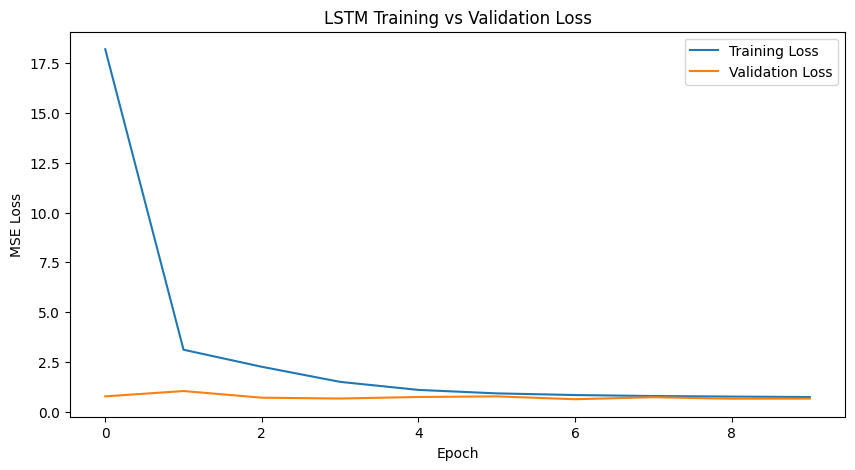

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
# Generate predictions on the test dataset

y_pred_lstm = lstm_model.predict(
    X_test_lstm,
    verbose=1
)

# Convert from (n, 1) to (n,)
y_pred_lstm = y_pred_lstm.flatten()

print("Prediction shape:", y_pred_lstm.shape)
print("Actual shape:", y_test_lstm.shape)

1001/1001 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
Prediction shape: (32011,)
Actual shape: (32011,)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lstm_mae = mean_absolute_error(
    y_test_lstm,
    y_pred_lstm
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_lstm,
        y_pred_lstm
    )
)

lstm_r2 = r2_score(
    y_test_lstm,
    y_pred_lstm
)

print("LSTM Test MAE :", lstm_mae)
print("LSTM Test RMSE:", lstm_rmse)
print("LSTM Test R²  :", lstm_r2)

LSTM Test MAE : 0.6444580351675891
LSTM Test RMSE: 0.8977187359229974
LSTM Test R²  : 0.9734299210092584


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "LSTM"
    ],
    "Test MAE": [
        0.5060708433,
        0.4325716560,
        0.4371238156,
        lstm_mae
    ],
    "Test RMSE": [
        0.7219107198,
        0.6585554425,
        0.6490346122,
        lstm_rmse
    ],
    "Test R2": [
        0.9828191461,
        0.9857024228,
        0.9861128387,
        lstm_r2
    ]
})

comparison

,Model,Test MAE,Test RMSE,Test R2
0,Linear Regression,0.506071,0.721911,0.982819
1,Random Forest,0.432572,0.658555,0.985702
2,XGBoost,0.437124,0.649035,0.986113
3,LSTM,0.644458,0.897719,0.973430


In [ ]:
# Create sequences for GRU

X_train_gru, y_train_gru = create_sequences(
    X_train_scaled,
    y_train,
    TIME_STEPS
)

X_val_gru, y_val_gru = create_sequences(
    X_val_scaled,
    y_val,
    TIME_STEPS
)

X_test_gru, y_test_gru = create_sequences(
    X_test_scaled,
    y_test,
    TIME_STEPS
)

print("X_train_gru:", X_train_gru.shape)
print("y_train_gru:", y_train_gru.shape)

print("X_val_gru:", X_val_gru.shape)
print("y_val_gru:", y_val_gru.shape)

print("X_test_gru:", X_test_gru.shape)
print("y_test_gru:", y_test_gru.shape)

X_train_gru: (131376, 24, 25)
y_train_gru: (131376,)
X_val_gru: (43776, 24, 25)
y_val_gru: (43776,)
X_test_gru: (32011, 24, 25)
y_test_gru: (32011,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense, Input

gru_model = Sequential([
    Input(shape=(TIME_STEPS, X_train_gru.shape[2])),
    
    GRU(64),
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    Dense(1)
])

gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        17,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,585 (76.50 KB)

 Trainable params: 19,585 (76.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

gru_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

gru_history = gru_model.fit(
    X_train_gru,
    y_train_gru,
    validation_data=(X_val_gru, y_val_gru),
    epochs=20,
    batch_size=64,
    callbacks=[gru_early_stopping],
    verbose=1
)

Epoch 1/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 21.4481 - mae: 2.4411 - val_loss: 0.9314 - val_mae: 0.7007
Epoch 2/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 3.2856 - mae: 1.4127 - val_loss: 0.8600 - val_mae: 0.6943
Epoch 3/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 2.4664 - mae: 1.2125 - val_loss: 0.8449 - val_mae: 0.6878
Epoch 4/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - loss: 1.6415 - mae: 0.9715 - val_loss: 0.7565 - val_mae: 0.6381
Epoch 5/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 1.1209 - mae: 0.7802 - val_loss: 0.6103 - val_mae: 0.5306
Epoch 6/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - loss: 0.9120 - mae: 0.6944 - val_loss: 0.6938 - val_mae: 0.5993
Epoch 7/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 69s 34ms/step - loss: 0.8510 - mae: 0.6638 - val_loss: 0.6406 - val_mae: 0.5700
Epoch 8/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 59s 29ms/step - loss: 0.8122 - mae: 0.6494 - val_loss: 0.6678 - val_mae: 0.5755


In [ ]:
print("Epochs completed:", len(gru_history.history["loss"]))

print("\nFinal Training Loss:", gru_history.history["loss"][-1])
print("Final Validation Loss:", gru_history.history["val_loss"][-1])

print("\nFinal Training MAE:", gru_history.history["mae"][-1])
print("Final Validation MAE:", gru_history.history["val_mae"][-1])

Epochs completed: 8

Final Training Loss: 0.8121956586837769
Final Validation Loss: 0.6678115725517273

Final Training MAE: 0.6494196057319641
Final Validation MAE: 0.5754526853561401


In [ ]:
y_pred_gru = gru_model.predict(
    X_test_gru,
    verbose=1
)

y_pred_gru = y_pred_gru.flatten()

print("Prediction shape:", y_pred_gru.shape)
print("Actual shape:", y_test_gru.shape)

1001/1001 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
Prediction shape: (32011,)
Actual shape: (32011,)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gru_mae = mean_absolute_error(
    y_test_gru,
    y_pred_gru
)

gru_rmse = np.sqrt(
    mean_squared_error(
        y_test_gru,
        y_pred_gru
    )
)

gru_r2 = r2_score(
    y_test_gru,
    y_pred_gru
)

print("GRU Test MAE :", gru_mae)
print("GRU Test RMSE:", gru_rmse)
print("GRU Test R²  :", gru_r2)

GRU Test MAE : 0.5900593682017092
GRU Test RMSE: 0.8685407297992414
GRU Test R²  : 0.975129034469869


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "LSTM",
        "GRU"
    ],
    "Test MAE": [
        0.5060708433,
        0.4325716560,
        0.4371238156,
        lstm_mae,
        gru_mae
    ],
    "Test RMSE": [
        0.7219107198,
        0.6585554425,
        0.6490346122,
        lstm_rmse,
        gru_rmse
    ],
    "Test R2": [
        0.9828191461,
        0.9857024228,
        0.9861128387,
        lstm_r2,
        gru_r2
    ]
})

comparison

,Model,Test MAE,Test RMSE,Test R2
0,Linear Regression,0.506071,0.721911,0.982819
1,Random Forest,0.432572,0.658555,0.985702
2,XGBoost,0.437124,0.649035,0.986113
3,LSTM,0.644458,0.897719,0.973430
4,GRU,0.590059,0.868541,0.975129


In [ ]:
# Hyperparameter tuning for XGBoost 
from xgboost import XGBRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05],
    "max_depth": [4, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid = list(ParameterGrid(param_grid))

print("Total combinations:", len(grid))

Total combinations: 32


In [ ]:
tuning_results = []

for i, params in enumerate(grid, start=1):

    print(f"Training model {i}/{len(grid)}...")

    model = XGBRegressor(
        **params,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    )

    model.fit(
        X_train,
        y_train,
        verbose=False
    )

    val_predictions = model.predict(X_val)

    mae = mean_absolute_error(
        y_val,
        val_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            val_predictions
        )
    )

    r2 = r2_score(
        y_val,
        val_predictions
    )

    tuning_results.append({
        "params": params,
        "Validation MAE": mae,
        "Validation RMSE": rmse,
        "Validation R2": r2
    })

print("\nTuning completed!")

Training model 1/32...
Training model 2/32...
Training model 3/32...
Training model 4/32...
Training model 5/32...
Training model 6/32...
Training model 7/32...
Training model 8/32...
Training model 9/32...
Training model 10/32...
Training model 11/32...
Training model 12/32...
Training model 13/32...
Training model 14/32...
Training model 15/32...
Training model 16/32...
Training model 17/32...
Training model 18/32...
Training model 19/32...
Training model 20/32...
Training model 21/32...
Training model 22/32...
Training model 23/32...
Training model 24/32...
Training model 25/32...
Training model 26/32...
Training model 27/32...
Training model 28/32...
Training model 29/32...
Training model 30/32...
Training model 31/32...
Training model 32/32...

Tuning completed!


In [ ]:
tuning_df = pd.DataFrame(tuning_results)

# Sort by validation RMSE
tuning_df = tuning_df.sort_values(
    by="Validation RMSE"
).reset_index(drop=True)

print("Top 10 XGBoost configurations:")
display(tuning_df.head(10))

Top 10 XGBoost configurations:


,params,Validation MAE,Validation RMSE,Validation R2
0,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.373614,0.571495,0.988882
1,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.372449,0.571764,0.988871
2,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.374939,0.571983,0.988863
3,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.374056,0.572401,0.988846
4,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.373031,0.572926,0.988826
5,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.375891,0.573101,0.988819
6,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.381598,0.577914,0.988630
7,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.380795,0.578362,0.988613
8,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",0.381434,0.578827,0.988595
9,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.382236,0.578888,0.988592


In [ ]:
best_row = tuning_df.iloc[0]

print("Best XGBoost parameters:")
print(best_row["params"])

print("\nValidation MAE :", best_row["Validation MAE"])
print("Validation RMSE:", best_row["Validation RMSE"])
print("Validation R²  :", best_row["Validation R2"])

Best XGBoost parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}

Validation MAE : 0.3736135028203329
Validation RMSE: 0.5714949045151134
Validation R²  : 0.9888816675029318


In [ ]:
best_xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

best_xgb_model.fit(
    X_train,
    y_train
)

print("Tuned XGBoost model trained successfully!")

Tuned XGBoost model trained successfully!


In [ ]:
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

print("Prediction shape:", y_pred_xgb_tuned.shape)
print("Actual shape:", y_test.shape)

Prediction shape: (32035,)
Actual shape: (32035,)


In [ ]:
xgb_tuned_mae = mean_absolute_error(
    y_test,
    y_pred_xgb_tuned
)

xgb_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb_tuned
    )
)

xgb_tuned_r2 = r2_score(
    y_test,
    y_pred_xgb_tuned
)

print("Tuned XGBoost Test MAE :", xgb_tuned_mae)
print("Tuned XGBoost Test RMSE:", xgb_tuned_rmse)
print("Tuned XGBoost Test R²  :", xgb_tuned_r2)

Tuned XGBoost Test MAE : 0.43170129509859306
Tuned XGBoost Test RMSE: 0.644401057896633
Tuned XGBoost Test R²  : 0.9863104159414726


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": [1.0, "sqrt"]
}

rf_grid = list(ParameterGrid(rf_param_grid))

print("Total Random Forest combinations:", len(rf_grid))

Total Random Forest combinations: 48


In [ ]:
rf_tuning_results = []

for i, params in enumerate(rf_grid, start=1):

    print(f"Training Random Forest {i}/{len(rf_grid)}...")

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    val_predictions = model.predict(X_val)

    mae = mean_absolute_error(
        y_val,
        val_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            val_predictions
        )
    )

    r2 = r2_score(
        y_val,
        val_predictions
    )

    rf_tuning_results.append({
        "params": params,
        "Validation MAE": mae,
        "Validation RMSE": rmse,
        "Validation R2": r2
    })

print("\nRandom Forest tuning completed!")

Training Random Forest 1/48...
Training Random Forest 2/48...
Training Random Forest 3/48...
Training Random Forest 4/48...
Training Random Forest 5/48...
Training Random Forest 6/48...
Training Random Forest 7/48...
Training Random Forest 8/48...
Training Random Forest 9/48...
Training Random Forest 10/48...
Training Random Forest 11/48...
Training Random Forest 12/48...
Training Random Forest 13/48...
Training Random Forest 14/48...
Training Random Forest 15/48...
Training Random Forest 16/48...
Training Random Forest 17/48...
Training Random Forest 18/48...
Training Random Forest 19/48...
Training Random Forest 20/48...
Training Random Forest 21/48...
Training Random Forest 22/48...
Training Random Forest 23/48...
Training Random Forest 24/48...
Training Random Forest 25/48...
Training Random Forest 26/48...
Training Random Forest 27/48...
Training Random Forest 28/48...
Training Random Forest 29/48...
Training Random Forest 30/48...
Training Random Forest 31/48...
Training Random F

In [ ]:
rf_tuning_df = pd.DataFrame(rf_tuning_results)

rf_tuning_df = rf_tuning_df.sort_values(
    by="Validation RMSE"
).reset_index(drop=True)

display(rf_tuning_df.head(10))

,params,Validation MAE,Validation RMSE,Validation R2
0,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.357953,0.556326,0.989464
1,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.358465,0.556607,0.989453
2,"{'max_depth': 25, 'max_features': 'sqrt', 'min...",0.358277,0.556744,0.989448
3,"{'max_depth': 25, 'max_features': 'sqrt', 'min...",0.359498,0.557510,0.989419
4,"{'max_depth': 25, 'max_features': 'sqrt', 'min...",0.358609,0.557555,0.989417
5,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.359203,0.557731,0.989411
6,"{'max_depth': 25, 'max_features': 'sqrt', 'min...",0.359557,0.557966,0.989402
7,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.359789,0.558019,0.989400
8,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.359873,0.558527,0.989381
9,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.360590,0.559021,0.989362


In [ ]:
best_rf_row = rf_tuning_df.iloc[0]

print("Best Random Forest parameters:")
print(best_rf_row["params"])

print("\nValidation MAE :", best_rf_row["Validation MAE"])
print("Validation RMSE:", best_rf_row["Validation RMSE"])
print("Validation R²  :", best_rf_row["Validation R2"])

Best Random Forest parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Validation MAE : 0.3579530455342952
Validation RMSE: 0.5563259696845504
Validation R²  : 0.9894640524570032


In [ ]:
print(type(rf_tuning_df))
print(rf_tuning_df.shape)

<class 'pandas.core.frame.DataFrame'>
(48, 4)


In [ ]:
best_rf_row = rf_tuning_df.iloc[0]

print("Best Random Forest parameters:")
print(best_rf_row["params"])

print("\nValidation MAE :", best_rf_row["Validation MAE"])
print("Validation RMSE:", best_rf_row["Validation RMSE"])
print("Validation R²  :", best_rf_row["Validation R2"])

Best Random Forest parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Validation MAE : 0.3579530455342952
Validation RMSE: 0.5563259696845504
Validation R²  : 0.9894640524570032


In [ ]:
best_rf_model = RandomForestRegressor(
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=2,
    min_samples_split=2,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

best_rf_model.fit(
    X_train,
    y_train
)

print("Tuned Random Forest training completed!")

Tuned Random Forest training completed!


In [ ]:
y_pred_rf_tuned = best_rf_model.predict(X_test)

rf_tuned_mae = mean_absolute_error(
    y_test,
    y_pred_rf_tuned
)

rf_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf_tuned
    )
)

rf_tuned_r2 = r2_score(
    y_test,
    y_pred_rf_tuned
)

print("Tuned Random Forest Test Results")
print("--------------------------------")
print("Test MAE :", rf_tuned_mae)
print("Test RMSE:", rf_tuned_rmse)
print("Test R²  :", rf_tuned_r2)

Tuned Random Forest Test Results
--------------------------------
Test MAE : 0.42050039678901463
Test RMSE: 0.6351040947386035
Test R²  : 0.9867025737910935


In [ ]:
lstm_configs = [
    {
        "units": 32,
        "dropout": 0.2,
        "dense_units": 16
    },
    {
        "units": 32,
        "dropout": 0.3,
        "dense_units": 16
    },
    {
        "units": 64,
        "dropout": 0.2,
        "dense_units": 32
    },
    {
        "units": 64,
        "dropout": 0.3,
        "dense_units": 32
    },
    {
        "units": 128,
        "dropout": 0.2,
        "dense_units": 32
    },
    {
        "units": 128,
        "dropout": 0.3,
        "dense_units": 64
    }
]

print("Total LSTM configurations:", len(lstm_configs))

Total LSTM configurations: 6


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lstm_tuning_results = []

for i, config in enumerate(lstm_configs, start=1):

    print(f"Training LSTM {i}/{len(lstm_configs)}...")

    model = Sequential([
        Input(shape=(
            TIME_STEPS,
            X_train_lstm.shape[2]
        )),
        LSTM(config["units"]),
        Dropout(config["dropout"]),
        Dense(config["dense_units"], activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    model.fit(
        X_train_lstm,
        y_train_lstm,
        validation_data=(
            X_val_lstm,
            y_val_lstm
        ),
        epochs=20,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=0
    )

    val_predictions = model.predict(
        X_val_lstm,
        verbose=0
    ).flatten()

    mae = mean_absolute_error(
        y_val_lstm,
        val_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val_lstm,
            val_predictions
        )
    )

    r2 = r2_score(
        y_val_lstm,
        val_predictions
    )

    lstm_tuning_results.append({
        "config": config,
        "Validation MAE": mae,
        "Validation RMSE": rmse,
        "Validation R2": r2
    })

print("\nLSTM tuning completed!")

Training LSTM 1/6...
Training LSTM 2/6...
Training LSTM 3/6...
Training LSTM 4/6...
Training LSTM 5/6...
Training LSTM 6/6...

LSTM tuning completed!


In [ ]:
lstm_tuning_df = pd.DataFrame(lstm_tuning_results)

lstm_tuning_df = lstm_tuning_df.sort_values(
    by="Validation RMSE"
).reset_index(drop=True)

display(lstm_tuning_df)

,config,Validation MAE,Validation RMSE,Validation R2
0,"{'units': 128, 'dropout': 0.3, 'dense_units': 64}",0.511575,0.751687,0.980762
1,"{'units': 128, 'dropout': 0.2, 'dense_units': 32}",0.516948,0.755355,0.980574
2,"{'units': 32, 'dropout': 0.3, 'dense_units': 16}",0.530733,0.773892,0.979609
3,"{'units': 64, 'dropout': 0.2, 'dense_units': 32}",0.541247,0.775702,0.979513
4,"{'units': 32, 'dropout': 0.2, 'dense_units': 16}",0.537331,0.776324,0.979480
5,"{'units': 64, 'dropout': 0.3, 'dense_units': 32}",0.543160,0.782582,0.979148


In [ ]:
best_lstm_row = lstm_tuning_df.iloc[0]

print("Best LSTM configuration:")
print(best_lstm_row["config"])

print("\nValidation MAE :", best_lstm_row["Validation MAE"])
print("Validation RMSE:", best_lstm_row["Validation RMSE"])
print("Validation R²  :", best_lstm_row["Validation R2"])

Best LSTM configuration:
{'units': 128, 'dropout': 0.3, 'dense_units': 64}

Validation MAE : 0.5115746899349997
Validation RMSE: 0.7516868661526557
Validation R²  : 0.9807619530846869


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

best_lstm_model = Sequential([
    Input(shape=(
        TIME_STEPS,
        X_train_lstm.shape[2]
    )),
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(1)
])

best_lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

best_lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

best_lstm_history = best_lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(
        X_val_lstm,
        y_val_lstm
    ),
    epochs=20,
    batch_size=64,
    callbacks=[best_lstm_early_stopping],
    verbose=1
)

Epoch 1/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 70s 33ms/step - loss: 12.0146 - mae: 1.8727 - val_loss: 0.7321 - val_mae: 0.6151
Epoch 2/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 70s 34ms/step - loss: 2.6002 - mae: 1.2485 - val_loss: 0.6888 - val_mae: 0.5807
Epoch 3/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 5078s 2s/step - loss: 1.8366 - mae: 1.0322 - val_loss: 0.7368 - val_mae: 0.6171
Epoch 4/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 64s 31ms/step - loss: 1.2349 - mae: 0.8309 - val_loss: 0.7182 - val_mae: 0.6006
Epoch 5/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 84s 41ms/step - loss: 0.9971 - mae: 0.7312 - val_loss: 0.7101 - val_mae: 0.6003


In [ ]:
y_pred_lstm_tuned = best_lstm_model.predict(
    X_test_lstm,
    verbose=1
).flatten()

lstm_tuned_mae = mean_absolute_error(
    y_test_lstm,
    y_pred_lstm_tuned
)

lstm_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test_lstm,
        y_pred_lstm_tuned
    )
)

lstm_tuned_r2 = r2_score(
    y_test_lstm,
    y_pred_lstm_tuned
)

print("Tuned LSTM Test Results")
print("-----------------------")
print("Test MAE :", lstm_tuned_mae)
print("Test RMSE:", lstm_tuned_rmse)
print("Test R²  :", lstm_tuned_r2)

1001/1001 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
Tuned LSTM Test Results
-----------------------
Test MAE : 0.6591130273038477
Test RMSE: 0.9259051438118574
Test R²  : 0.971735242703636


In [ ]:
gru_configs = [
    {
        "units": 32,
        "dropout": 0.2,
        "dense_units": 16
    },
    {
        "units": 32,
        "dropout": 0.3,
        "dense_units": 16
    },
    {
        "units": 64,
        "dropout": 0.2,
        "dense_units": 32
    },
    {
        "units": 64,
        "dropout": 0.3,
        "dense_units": 32
    },
    {
        "units": 128,
        "dropout": 0.2,
        "dense_units": 32
    },
    {
        "units": 128,
        "dropout": 0.3,
        "dense_units": 64
    }
]

print("Total GRU configurations:", len(gru_configs))

Total GRU configurations: 6


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

gru_tuning_results = []

for i, config in enumerate(gru_configs, start=1):

    print(f"Training GRU {i}/{len(gru_configs)}...")

    model = Sequential([
        Input(shape=(
            TIME_STEPS,
            X_train_gru.shape[2]
        )),
        GRU(config["units"]),
        Dropout(config["dropout"]),
        Dense(config["dense_units"], activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    model.fit(
        X_train_gru,
        y_train_gru,
        validation_data=(
            X_val_gru,
            y_val_gru
        ),
        epochs=20,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=0
    )

    val_predictions = model.predict(
        X_val_gru,
        verbose=0
    ).flatten()

    mae = mean_absolute_error(
        y_val_gru,
        val_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val_gru,
            val_predictions
        )
    )

    r2 = r2_score(
        y_val_gru,
        val_predictions
    )

    gru_tuning_results.append({
        "config": config,
        "Validation MAE": mae,
        "Validation RMSE": rmse,
        "Validation R2": r2
    })

print("\nGRU tuning completed!")

Training GRU 1/6...
Training GRU 2/6...
Training GRU 3/6...
Training GRU 4/6...
Training GRU 5/6...
Training GRU 6/6...

GRU tuning completed!


In [ ]:
gru_tuning_df = pd.DataFrame(gru_tuning_results)

gru_tuning_df = gru_tuning_df.sort_values(
    by="Validation RMSE"
).reset_index(drop=True)

display(gru_tuning_df)

,config,Validation MAE,Validation RMSE,Validation R2
0,"{'units': 64, 'dropout': 0.2, 'dense_units': 32}",0.510539,0.751079,0.980793
1,"{'units': 32, 'dropout': 0.2, 'dense_units': 16}",0.541806,0.782738,0.979140
2,"{'units': 64, 'dropout': 0.3, 'dense_units': 32}",0.544601,0.786952,0.978915
3,"{'units': 128, 'dropout': 0.3, 'dense_units': 64}",0.551505,0.792308,0.978627
4,"{'units': 32, 'dropout': 0.3, 'dense_units': 16}",0.556907,0.799571,0.978233
5,"{'units': 128, 'dropout': 0.2, 'dense_units': 32}",0.570418,0.810598,0.977628


In [ ]:
best_gru_model = Sequential([
    Input(shape=(
        TIME_STEPS,
        X_train_gru.shape[2]
    )),
    GRU(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

best_gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

best_gru_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

best_gru_history = best_gru_model.fit(
    X_train_gru,
    y_train_gru,
    validation_data=(
        X_val_gru,
        y_val_gru
    ),
    epochs=20,
    batch_size=64,
    callbacks=[best_gru_early_stopping],
    verbose=1
)

Epoch 1/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - loss: 25.1960 - mae: 2.7860 - val_loss: 1.4073 - val_mae: 0.8941
Epoch 2/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - loss: 4.0681 - mae: 1.5773 - val_loss: 1.0197 - val_mae: 0.7689
Epoch 3/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - loss: 3.0036 - mae: 1.3480 - val_loss: 0.8868 - val_mae: 0.7165
Epoch 4/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - loss: 2.1875 - mae: 1.1383 - val_loss: 1.9703 - val_mae: 1.2351
Epoch 5/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - loss: 1.4659 - mae: 0.9131 - val_loss: 0.7145 - val_mae: 0.6154
Epoch 6/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - loss: 1.0295 - mae: 0.7428 - val_loss: 0.6750 - val_mae: 0.5944
Epoch 7/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - loss: 0.8740 - mae: 0.6772 - val_loss: 0.6124 - val_mae: 0.5422
Epoch 8/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - loss: 0.8155 - mae: 0.6510 - val_loss: 0.6926 - val_mae: 0.5995
Epoch 9/20
2053/2053 ━━

In [ ]:
y_pred_gru_tuned = best_gru_model.predict(
    X_test_gru,
    verbose=1
).flatten()

gru_tuned_mae = mean_absolute_error(
    y_test_gru,
    y_pred_gru_tuned
)

gru_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test_gru,
        y_pred_gru_tuned
    )
)

gru_tuned_r2 = r2_score(
    y_test_gru,
    y_pred_gru_tuned
)

print("Tuned GRU Test Results")
print("----------------------")
print("Test MAE :", gru_tuned_mae)
print("Test RMSE:", gru_tuned_rmse)
print("Test R²  :", gru_tuned_r2)

1001/1001 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Tuned GRU Test Results
----------------------
Test MAE : 0.5994304499710025
Test RMSE: 0.8723513974146003
Test R²  : 0.9749103161316808


In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest (Tuned)",
        "XGBoost (Tuned)",
        "LSTM (Tuned)",
        "GRU (Tuned)"
    ],
    "Test MAE": [
        0.5060708433,
        rf_tuned_mae,
        0.4317012951,
        lstm_tuned_mae,
        gru_tuned_mae
    ],
    "Test RMSE": [
        0.7219107198,
        rf_tuned_rmse,
        0.6444010579,
        lstm_tuned_rmse,
        gru_tuned_rmse
    ],
    "Test R2": [
        0.9828191461,
        rf_tuned_r2,
        0.9863104159,
        lstm_tuned_r2,
        gru_tuned_r2
    ]
})

display(final_comparison)

,Model,Test MAE,Test RMSE,Test R2
0,Linear Regression,0.506071,0.721911,0.982819
1,Random Forest (Tuned),0.420500,0.635104,0.986703
2,XGBoost (Tuned),0.431701,0.644401,0.986310
3,LSTM (Tuned),0.659113,0.925905,0.971735
4,GRU (Tuned),0.599430,0.872351,0.974910


In [ ]:
import os
import joblib

# Check that the models folder exists
os.makedirs("../models", exist_ok=True)

print("Models folder is ready.")

Models folder is ready.


In [ ]:
joblib.dump(
    best_rf_model,
    "../models/random_forest.pkl"
)

print("Random Forest model saved successfully!")



Random Forest model saved successfully!


In [ ]:
joblib.dump(
    best_xgb_model,
    "../models/xgboost.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [ ]:
best_lstm_model.save(
    "../models/lstm.keras"
)

print("LSTM model saved successfully!")

LSTM model saved successfully!


In [ ]:
best_gru_model.save(
    "../models/gru.keras"
)

print("GRU model saved successfully!")

GRU model saved successfully!


In [ ]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [ ]:
joblib.dump(
    linear_model,
    "../models/linear_regression.pkl"
)

print("Linear Regression model saved successfully!")

Linear Regression model saved successfully!


In [ ]:
import json

with open("../models/feature_columns.json", "w") as f:
    json.dump(features, f, indent=4)

print("Feature configuration saved successfully!")

Feature configuration saved successfully!


In [ ]:
xgb_test_pred = xgb_model.predict(X_test_scaled)

print("First 10 predictions:")
print(xgb_test_pred[:10])

print("\nFirst 10 actual values:")
print(y_test.iloc[:10].values)

First 10 predictions:
[5.0388417 4.982493  4.982493  5.034396  5.0644445 5.4552574 5.567897
 7.469374  7.449242  7.440141 ]

First 10 actual values:
[19.9 19.3 19.  18.8 19.1 19.  19.5 21.3 23.2 24.2]


In [ ]:
print("Prediction minimum:", xgb_test_pred.min())
print("Prediction maximum:", xgb_test_pred.max())
print("Prediction mean:", xgb_test_pred.mean())

print("\nActual minimum:", y_test.min())
print("Actual maximum:", y_test.max())
print("Actual mean:", y_test.mean())

Prediction minimum: 4.636375
Prediction maximum: 8.098768
Prediction mean: 6.32256

Actual minimum: 4.9
Actual maximum: 44.4
Actual mean: 27.221854221944742
